# 🔢 NumPy, Pandas & Matplotlib – Exercises
A hands-on notebook covering matrix operations, statistics, dates, visualisation, and more.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

np.random.seed(42)


## 🌟 Exercise 1 – Matrix Operations

**Concepts**
- **Determinant** – a scalar that encodes key properties of a square matrix (e.g. whether an inverse exists).
- **Inverse** – the matrix `A⁻¹` such that `A @ A⁻¹ = I`.  Only exists when `det(A) ≠ 0`.


In [2]:
# 3x3 matrix
A = np.array([[2, 1, 3],
              [1, 4, 2],
              [3, 2, 5]])

det_A = np.linalg.det(A)
print(f"Matrix A:\n{A}\n")
print(f"Determinant of A: {det_A:.4f}")

if abs(det_A) > 1e-9:          # non-zero → invertible
    inv_A = np.linalg.inv(A)
    print(f"\nInverse of A:\n{np.round(inv_A, 4)}")

    # Verification: A @ A⁻¹ should equal the identity matrix
    identity_check = np.round(A @ inv_A, 6)
    print(f"\nVerification  A @ A⁻¹ (should be Identity):\n{identity_check}")
else:
    print("Matrix is singular – no inverse exists.")


Matrix A:
[[2 1 3]
 [1 4 2]
 [3 2 5]]

Determinant of A: 3.0000

Inverse of A:
[[ 5.3333  0.3333 -3.3333]
 [ 0.3333  0.3333 -0.3333]
 [-3.3333 -0.3333  2.3333]]

Verification  A @ A⁻¹ (should be Identity):
[[ 1. -0.  0.]
 [ 0.  1.  0.]
 [-0. -0.  1.]]


## 🌟 Exercise 2 – Statistical Analysis

Generate 50 random numbers and compute mean, median, and standard deviation.


In [3]:
data = np.random.randint(1, 101, size=50)   # 50 integers between 1 and 100
print(f"Dataset (50 values):\n{data}\n")

mean   = np.mean(data)
median = np.median(data)
std    = np.std(data)

print(f"Mean:               {mean:.2f}")
print(f"Median:             {median:.2f}")
print(f"Standard Deviation: {std:.2f}")


Dataset (50 values):
[ 52  93  15  72  61  21  83  87  75  75  88 100  24   3  22  53   2  88
  30  38   2  64  60  21  33  76  58  22  89  49  91  59  42  92  60  80
  15  62  62  47  62  51  55  64   3  51   7  21  73  39]

Mean:               51.84
Median:             56.50
Standard Deviation: 27.85


## 🌟 Exercise 3 – Date Manipulation

Create an array of every day in January 2023 and reformat the dates from `YYYY-MM-DD` to `YYYY/MM/DD`.


In [4]:
# All days in January 2023
jan_dates = np.arange("2023-01", "2023-02", dtype="datetime64[D]")
print(f"Original format (datetime64):\n{jan_dates}\n")

# Convert to YYYY/MM/DD strings
reformatted = np.array([str(d).replace("-", "/") for d in jan_dates])
print(f"Reformatted (YYYY/MM/DD):\n{reformatted}")


Original format (datetime64):
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10'
 '2023-01-11' '2023-01-12' '2023-01-13' '2023-01-14' '2023-01-15'
 '2023-01-16' '2023-01-17' '2023-01-18' '2023-01-19' '2023-01-20'
 '2023-01-21' '2023-01-22' '2023-01-23' '2023-01-24' '2023-01-25'
 '2023-01-26' '2023-01-27' '2023-01-28' '2023-01-29' '2023-01-30'
 '2023-01-31']

Reformatted (YYYY/MM/DD):
['2023/01/01' '2023/01/02' '2023/01/03' '2023/01/04' '2023/01/05'
 '2023/01/06' '2023/01/07' '2023/01/08' '2023/01/09' '2023/01/10'
 '2023/01/11' '2023/01/12' '2023/01/13' '2023/01/14' '2023/01/15'
 '2023/01/16' '2023/01/17' '2023/01/18' '2023/01/19' '2023/01/20'
 '2023/01/21' '2023/01/22' '2023/01/23' '2023/01/24' '2023/01/25'
 '2023/01/26' '2023/01/27' '2023/01/28' '2023/01/29' '2023/01/30'
 '2023/01/31']


## 🌟 Exercise 4 – Data Manipulation with NumPy and Pandas

Create a DataFrame of random numbers, apply conditional selection, and run aggregation functions.


In [5]:
# DataFrame: 5 rows x 4 columns, values 1–100
df = pd.DataFrame(
    np.random.randint(1, 101, size=(5, 4)),
    columns=["A", "B", "C", "D"]
)
print("DataFrame:\n", df, "\n")

# ── Conditional selection: rows where column A > 50
print("Rows where A > 50:\n", df[df["A"] > 50], "\n")

# ── Aggregation
print("Column sums:\n",     df.sum(),  "\n")
print("Column averages:\n", df.mean(), "\n")


DataFrame:
     A   B   C   D
0  18   4  89  60
1  14   9  90  53
2   2  84  92  60
3  71  44   8  47
4  35  78  81  36 

Rows where A > 50:
     A   B  C   D
3  71  44  8  47 

Column sums:
 A    140
B    219
C    360
D    256
dtype: int64 

Column averages:
 A    28.0
B    43.8
C    72.0
D    51.2
dtype: float64 



## 🌟 Exercise 5 – Image Representation

**How images are stored in NumPy**

| Image type | Array shape | Value range |
|------------|-------------|-------------|
| Grayscale  | `(H, W)`    | 0 (black) – 255 (white) |
| RGB colour | `(H, W, 3)` | one channel each for R, G, B |
| RGBA       | `(H, W, 4)` | R, G, B + alpha (transparency) |

Each element is a pixel intensity.  We demonstrate with a hand-crafted 5 × 5 grayscale image.


Image array (pixel intensities):
[[  0  50 100 150 200]
 [ 50 100 150 200 250]
 [100 150 200 250 255]
 [150 200 250 255 200]
 [200 250 255 200 150]]

Shape: (5, 5)  |  dtype: uint8
Min pixel: 0  |  Max pixel: 255


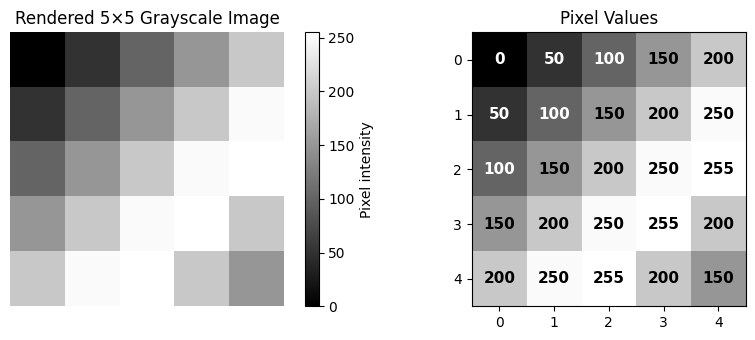

In [6]:
# 5x5 grayscale image (0 = black, 255 = white)
image = np.array([
    [  0,  50, 100, 150, 200],
    [ 50, 100, 150, 200, 250],
    [100, 150, 200, 250, 255],
    [150, 200, 250, 255, 200],
    [200, 250, 255, 200, 150]
], dtype=np.uint8)

print(f"Image array (pixel intensities):\n{image}\n")
print(f"Shape: {image.shape}  |  dtype: {image.dtype}")
print(f"Min pixel: {image.min()}  |  Max pixel: {image.max()}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Left: rendered grayscale image
axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Rendered 5×5 Grayscale Image")
axes[0].axis("off")
plt.colorbar(axes[0].images[0], ax=axes[0], label="Pixel intensity")

# Right: pixel-value heatmap with annotations
im = axes[1].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Pixel Values")
for i in range(5):
    for j in range(5):
        val = image[i, j]
        colour = "white" if val < 128 else "black"
        axes[1].text(j, i, str(val), ha="center", va="center",
                     fontsize=11, color=colour, fontweight="bold")
axes[1].set_xticks(range(5))
axes[1].set_yticks(range(5))

plt.tight_layout()
plt.savefig("ex5_image.png", dpi=120, bbox_inches="tight")
plt.show()


## 🌟 Exercise 6 – Basic Hypothesis Testing

**Scenario:** Did a training programme improve employee productivity?

**Hypotheses**
- **H₀ (null):** No improvement – mean productivity after = mean productivity before.  
- **H₁ (alternative):** Productivity improved – mean after > mean before.

We use a **paired t-test** (same employees measured twice) at significance level **α = 0.05**.


Before – Mean: 51.04, Std: 9.38
After  – Mean: 56.29, Std: 10.43
Mean improvement: 5.25 points

t-statistic : 10.0777
p-value (one-sided): 0.000000

✅ Reject H₀  (p = 0.0000 < α = 0.05)
   The training programme significantly improved productivity.


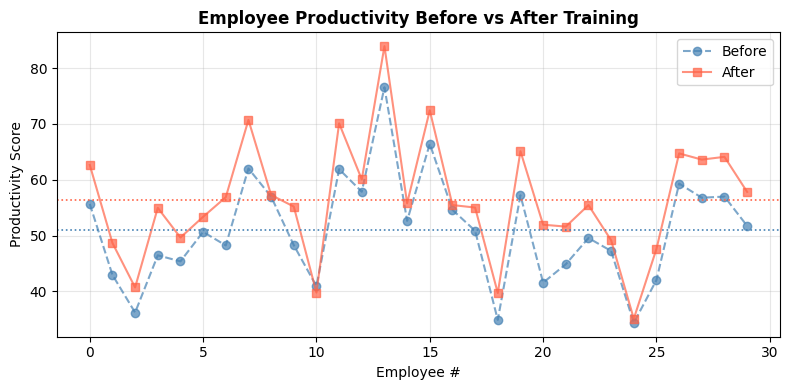

In [7]:
productivity_before = np.random.normal(loc=50, scale=10, size=30)
productivity_after  = productivity_before + np.random.normal(loc=5, scale=3, size=30)

print(f"Before – Mean: {productivity_before.mean():.2f}, Std: {productivity_before.std():.2f}")
print(f"After  – Mean: {productivity_after.mean():.2f}, Std: {productivity_after.std():.2f}")
print(f"Mean improvement: {(productivity_after - productivity_before).mean():.2f} points\n")

# Paired t-test (one-sided: after > before)
t_stat, p_value_two = stats.ttest_rel(productivity_after, productivity_before)
p_value_one = p_value_two / 2   # one-sided

alpha = 0.05
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value (one-sided): {p_value_one:.6f}")
print()
if p_value_one < alpha:
    print(f"✅ Reject H₀  (p = {p_value_one:.4f} < α = {alpha})")
    print("   The training programme significantly improved productivity.")
else:
    print(f"❌ Fail to reject H₀  (p = {p_value_one:.4f} ≥ α = {alpha})")
    print("   No statistically significant improvement detected.")

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(productivity_before, "o--", label="Before", alpha=0.7, color="steelblue")
ax.plot(productivity_after,  "s-",  label="After",  alpha=0.7, color="tomato")
ax.axhline(productivity_before.mean(), linestyle=":", color="steelblue", linewidth=1.2)
ax.axhline(productivity_after.mean(),  linestyle=":", color="tomato",    linewidth=1.2)
ax.set_title("Employee Productivity Before vs After Training", fontsize=12, fontweight="bold")
ax.set_xlabel("Employee #")
ax.set_ylabel("Productivity Score")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ex6_hypothesis.png", dpi=120, bbox_inches="tight")
plt.show()


## 🌟 Exercise 7 – Complex Array Comparison

Create two arrays and find element-wise which values in the first array are greater.


In [8]:
arr1 = np.random.randint(1, 20, size=8)
arr2 = np.random.randint(1, 20, size=8)

print(f"Array 1:              {arr1}")
print(f"Array 2:              {arr2}")

comparison = arr1 > arr2
print(f"arr1 > arr2 (bool):   {comparison}")
print(f"Elements where arr1 > arr2: {arr1[comparison]}")
print(f"Count: {comparison.sum()} out of {len(arr1)}")


Array 1:              [10 13  6 12 12 11  7  1]
Array 2:              [ 1 13  9  3  7  6  8  9]
arr1 > arr2 (bool):   [ True False False  True  True  True False False]
Elements where arr1 > arr2: [10 12 12 11]
Count: 4 out of 8


## 🌟 Exercise 8 – Time Series Data Manipulation

Generate daily time series data for 2023 and slice it into quarters.


Q1  Jan–Mar  |  Days: 90  |  Mean: 99.9  |  Min: 50  Max: 148
Q2  Apr–Jun  |  Days: 91  |  Mean: 99.2  |  Min: 52  Max: 149
Q3  Jul–Sep  |  Days: 92  |  Mean: 97.7  |  Min: 51  Max: 148
Q4  Oct–Dec  |  Days: 92  |  Mean: 99.6  |  Min: 50  Max: 149


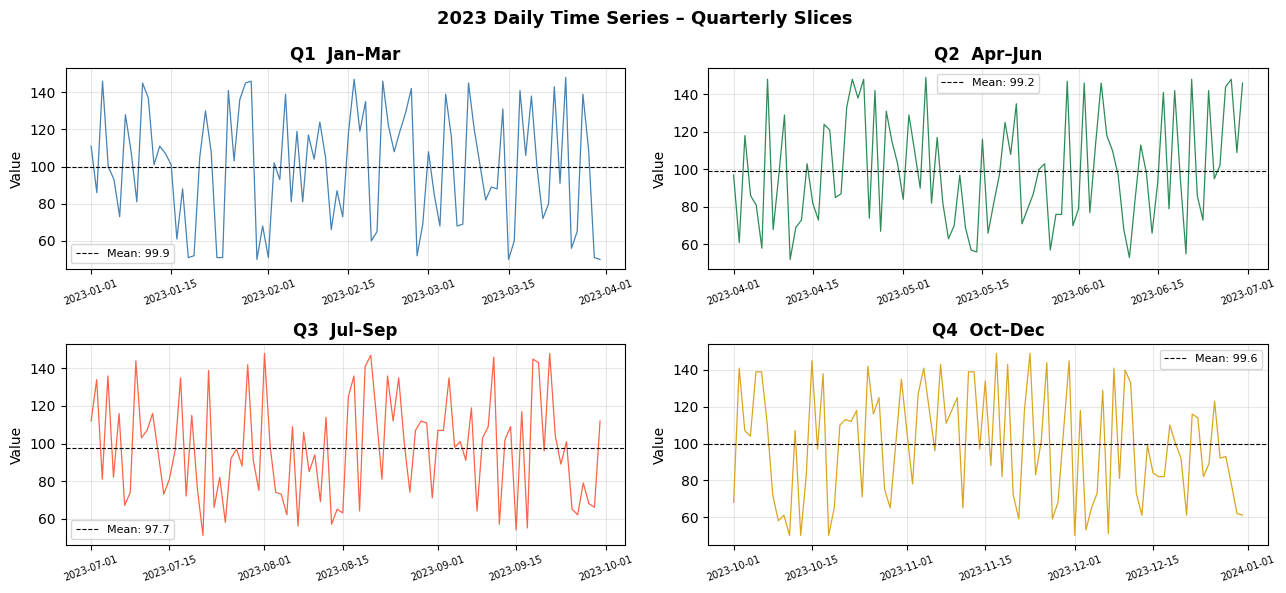

In [9]:
# Daily dates for the whole of 2023
dates  = np.arange("2023-01-01", "2024-01-01", dtype="datetime64[D]")
values = np.random.randint(50, 150, size=len(dates))   # simulated daily metric

ts = pd.Series(values, index=pd.to_datetime(dates), name="Daily Metric")

quarters = {
    "Q1  Jan–Mar": ts["2023-01":"2023-03"],
    "Q2  Apr–Jun": ts["2023-04":"2023-06"],
    "Q3  Jul–Sep": ts["2023-07":"2023-09"],
    "Q4  Oct–Dec": ts["2023-10":"2023-12"],
}

for label, q in quarters.items():
    print(f"{label}  |  Days: {len(q)}  |  Mean: {q.mean():.1f}  |  "
          f"Min: {q.min()}  Max: {q.max()}")

# Plot all quarters
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=False)
colors = ["steelblue", "seagreen", "tomato", "goldenrod"]
for ax, (label, q), color in zip(axes.flat, quarters.items(), colors):
    ax.plot(q.index, q.values, color=color, linewidth=0.9)
    ax.axhline(q.mean(), linestyle="--", color="black", linewidth=0.8,
               label=f"Mean: {q.mean():.1f}")
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Value")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=20, labelsize=7)

fig.suptitle("2023 Daily Time Series – Quarterly Slices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ex8_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()


## 🌟 Exercise 9 – Data Conversion

Convert between NumPy arrays and Pandas DataFrames in both directions.


In [10]:
# ── NumPy → Pandas ──────────────────────────────────────────────────────────
np_array = np.array([[10, 20, 30],
                     [40, 50, 60],
                     [70, 80, 90]])

df_from_np = pd.DataFrame(np_array, columns=["X", "Y", "Z"])
print("NumPy array:\n", np_array)
print("\nConverted to DataFrame:\n", df_from_np)

# ── Pandas → NumPy ──────────────────────────────────────────────────────────
df_sample = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6], "C": [7, 8, 9]})
np_from_df = df_sample.to_numpy()

print("\nDataFrame:\n", df_sample)
print("\nConverted back to NumPy array:\n", np_from_df)
print("Type:", type(np_from_df), "| dtype:", np_from_df.dtype)


NumPy array:
 [[10 20 30]
 [40 50 60]
 [70 80 90]]

Converted to DataFrame:
     X   Y   Z
0  10  20  30
1  40  50  60
2  70  80  90

DataFrame:
    A  B  C
0  1  4  7
1  2  5  8
2  3  6  9

Converted back to NumPy array:
 [[1 4 7]
 [2 5 8]
 [3 6 9]]
Type: <class 'numpy.ndarray'> | dtype: int64


## 🌟 Exercise 10 – Basic Visualization

Use Matplotlib to plot a line graph of random numbers alongside a smoothed trend line.


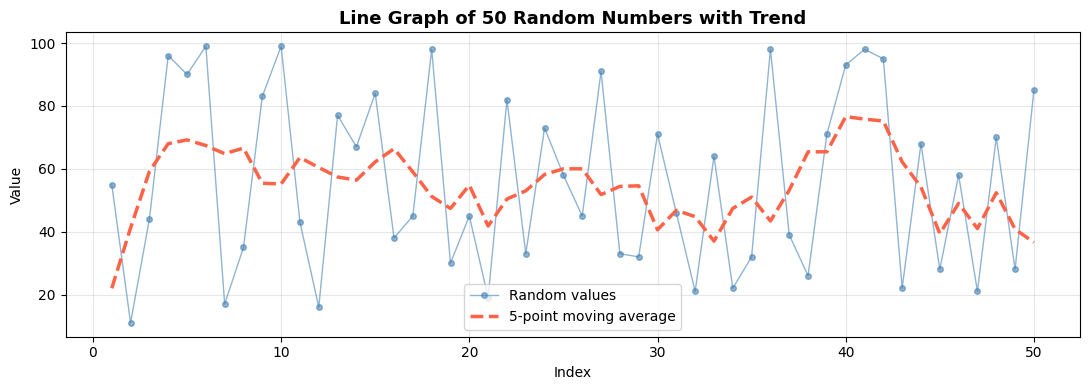

In [11]:
x      = np.arange(1, 51)
y      = np.random.randint(10, 100, size=50)
trend  = np.convolve(y, np.ones(5)/5, mode="same")   # 5-point moving average

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(x, y,     marker="o", markersize=4, linewidth=1,   color="steelblue",
        alpha=0.6, label="Random values")
ax.plot(x, trend, linewidth=2.5, color="tomato", linestyle="--",
        label="5-point moving average")

ax.set_title("Line Graph of 50 Random Numbers with Trend", fontsize=13, fontweight="bold")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ex10_visualization.png", dpi=120, bbox_inches="tight")
plt.show()
